# Modelado del Potencial de Acción del Electrocardiograma (ECG)

El latido del corazón humano es orquestado por un sistema eléctrico complejo. Células especializadas en el **nodo sinoauricular (SA)** generan impulsos rítmicos que viajan a través de las aurículas, el **nodo auriculoventricular (AV)** y, finalmente, la **red de His-Purkinje**, provocando la contracción de los ventrículos. Esta actividad eléctrica puede registrarse sobre la piel como un **electrocardiograma (ECG)**, una herramienta diagnóstica vital para detectar trastornos cardíacos.

## El sistema de reacción-difusión
En este caso implementamos un modelo matemático propuesto por {cite:t}`quiroz2019generation` que genera señales de ECG realistas. El modelo parte de un sistema genérico de reacción-difusión (el modelo BVAM) y, tras la discretización espacial y reducciones de simetría, produce un conjunto compacto de cuatro ecuaciones diferenciales ordinarias (Ecuación 3 del artículo)

```{math}
 :label: bvam
 \begin{aligned}
  \dot{x}_1 &= x_1 - x_2 - Cx_1x_2 - x_1x_2^2, \\
  \dot{x}_2 &= Hx_1 - 3x_2 + Cx_1x_2 + x_1x_2^2 + \beta(x_4 - x_2), \\
  \dot{x}_3 &= x_3 - x_4 - Cx_3x_4 - x_3x_4^2, \\
  \dot{x}_4 &= Hx_3 - 3x_4 + Cx_3x_4 + x_3x_4^2 + 2\beta(x_2 - x_4).
 \end{aligned}
```

Estas cuatro variables representan la actividad eléctrica de las dos principales regiones marcapasos (el nodo SA y el nodo AV) tras una reducción adicional de tres a dos osciladores. La señal de ECG en sí misma se toma como una **combinación lineal** de las variables de estado (Ecuación 4)

```{math}
:label: ecg
 ECG(t) = \alpha_1 x_1(t) + \alpha_2 x_2(t) + \alpha_3 x_3(t) + \alpha_4 x_4(t),
```

donde los coeficientes $\alpha_i$ determinan la contribución de cada componente a la derivación registrada (en este caso, la derivación II). Los parámetros $H$ y $C$ controlan la dinámica local, mientras que $\beta$ gobierna el acoplamiento entre los osciladores. Al variar $H$, el sistema puede producir un rico repertorio de comportamientos: desde el ritmo sinusal normal hasta dinámicas periódicas, cuasiperiódicas y caóticas que imitan arritmias reales como taquicardia, aleteo (*flutter*) y fibrilación.

Un factor de escala temporal $\Gamma_t$ (que depende linealmente de la frecuencia cardíaca) convierte el tiempo de simulación adimensional en segundos reales, proporcionando trazados de ECG con duraciones fisiológicamente correctas.

La metodología para modelar este sistema está dada como sigue:

1. **Implementar el sistema de EDO de cuatro variables** (Ecuación 3) en Python usando `scipy.integrate.solve_ivp`.
2. **Simular un ritmo sinusal normal** con los parámetros tomados del artículo original.
3. **Calcular y graficar el ECG correspondiente** (Ecuación 4) tras aplicar el factor de escala temporal.
4. No se consideran las diversas arritmias enumeradas en la Tabla 1 del artículo (taquicardia sinusal, aleteo auricular, taquicardia ventricular, aleteo ventricular) con el fin de ilustrar la versatilidad del modelo, pero se reconoce como un posible **trabajo futuro**.

Escribiremos una función que devuelva las derivadas para un tiempo `t` y un vector de estado `y = [x1, x2, x3, x4]`. Los parámetros `C`, `H` y `beta` se pasarán como argumentos.

::::{important}
Es necesario instalar la librería `wfdb` para poder ejecutar este cuaderno de forma local. Puedes instalarla ejecutando el siguiente comando en tu terminal:
 ```bash
  pip install wfdb
 ```
 
 o si estás trabajando en Jupyter Notebook

 ```bash
  !pip install wfdb
 ```
::::

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp
from scipy.stats import linregress
from scipy.signal import find_peaks
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize, differential_evolution
from scipy.optimize import differential_evolution
from sklearn.metrics import mean_squared_error
from scipy.special import gamma
from scipy.interpolate import interp1d
from matplotlib.widgets import Slider, Button
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
import wfdb
import pandas as pd

# Suprimir advertencias menores de integración durante los bucles de optimización
warnings.filterwarnings("ignore")

# Configurar el estilo de graficación para una mejor visualización
plt.style.use('ggplot')

In [17]:
def heart_ode(t, y, C, H, beta):
    """
    ODE for the reduced four‑variable heart model (Eq. 3).
    y = [x1, x2, x3, x4]
    """
    x1, x2, x3, x4 = y

    dx1 = x1 - x2 - C*x1*x2 - x1*x2**2
    dx2 = H*x1 - 3*x2 + C*x1*x2 + x1*x2**2 + beta*(x4 - x2)
    dx3 = x3 - x4 - C*x3*x4 - x3*x4**2
    dx4 = H*x3 - 3*x4 + C*x3*x4 + x3*x4**2 + 2*beta*(x2 - x4)

    return [dx1, dx2, dx3, dx4]

## Parámetros para el ritmo sinusal normal
De acuerdo con el artículo:

* $C = 1.35$.
* $\beta = 4$.
* $H = 3$ (ritmo normal, ver pie de la Fig. 4).
* Factor de escala temporal $\Gamma_t = 7$ (para obtener un ECG en tiempo real)
* Coeficientes de mezcla $\alpha_i$ (del texto posterior a la Fig. 4):
  ```{math}
   \alpha_1 = -0.024, \alpha_2 = 0.0216, \alpha_3 = -0.0012, \alpha_4 = 0.12.
  ```
* Condición inicial: una pequeña perturbación alrededor del equilibrio $(0, 0, 0, 0)$.

Seleccionamos $x_4(0) = 0.1$ (dado que en el artículo utilizaron un estado perturbado). Esto debería ser suficiente para excitar el sistema.

In [18]:
# Parámetros fijos del modelo
C = 1.35
beta = 4

# Parámetros específicos del ritmo (sinusal normal)
H_normal = 3
alpha = [-0.024, 0.0216, -0.0012, 0.12]
Gamma_t = 6

# Configuración del tiempo (adimensional)
t_start = 0.0
t_end = 1000          # suficiente para observar varios latidos tras el escalamiento
t_points = 100000     # alta resolución
t_nondim = np.linspace(t_start, t_end, t_points)

# Condición inicial (pequeña perturbación en x3 según el artículo)
y0 = [0.0, 0.0, 0.1, 0.0]   # x4 perturbada inicialmente

Primero resolvemos las ecuaciones adimensionales. Posteriormente, escalaremos el eje del tiempo a segundos reales utilizando $\Gamma_t$.

In [19]:
# Resolver EDO - usando 'BDF' para osciladores de relajación rígidos e imponiendo max_step
sol = solve_ivp(
    heart_ode,
    [t_start, t_end],
    y0,
    t_eval=t_nondim,
    args=(C, H_normal, beta),
    method='BDF',        # Cambio crítico: Solver para ecuaciones rígidas (stiff)
    max_step=0.05,       # Cambio crítico: Evita omitir los picos positivos pronunciados
    rtol=1e-6,
    atol=1e-8
)

# Extraer la solución completa
t_full = sol.t
x1_full, x2_full, x3_full, x4_full = sol.y

Graficamos las cuatro variables para observar sus formas de onda.

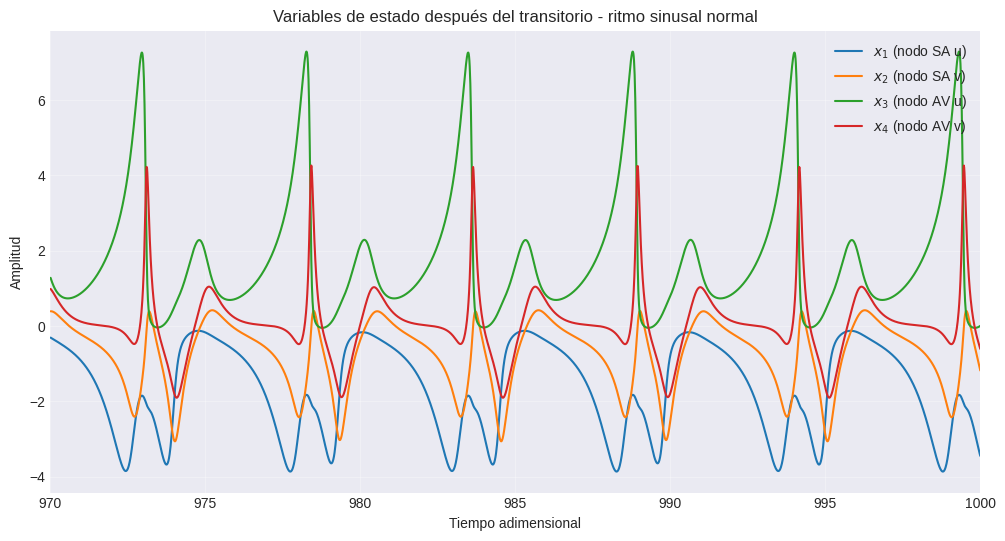

In [20]:
# Seleccionar índices después del transitorio
t_start_plot = 970    # aumentar el número para enfocarse en menos o más ondas
mask = t_full >= t_start_plot
t_steady = t_full[mask]
x1_steady = x1_full[mask]
x2_steady = x2_full[mask]
x3_steady = x3_full[mask]
x4_steady = x4_full[mask]

plt.figure(figsize=(12, 6))
# Se corrigieron los nombres de las variables indefinidas aquí
plt.plot(t_steady, x1_steady, label='$x_1$ (nodo SA u)')
plt.plot(t_steady, x2_steady, label='$x_2$ (nodo SA v)')
plt.plot(t_steady, x3_steady, label='$x_3$ (nodo AV u)')
plt.plot(t_steady, x4_steady, label='$x_4$ (nodo AV v)')
plt.xlabel('Tiempo adimensional')
plt.ylabel('Amplitud')
plt.title('Variables de estado después del transitorio - ritmo sinusal normal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(t_start_plot, t_steady[-1])
plt.show()

## Calcular y graficar la señal de ECG (tiempo real)

Tomando en cuenta la Ec. {eq}`ecg`, es necesario convertir el tiempo adimensional a segundos reales utilizando el factor de escala

```{math}
 t_{\text{real}} = \frac{t_{\text{nondim}}}{\Gamma_t}.
```

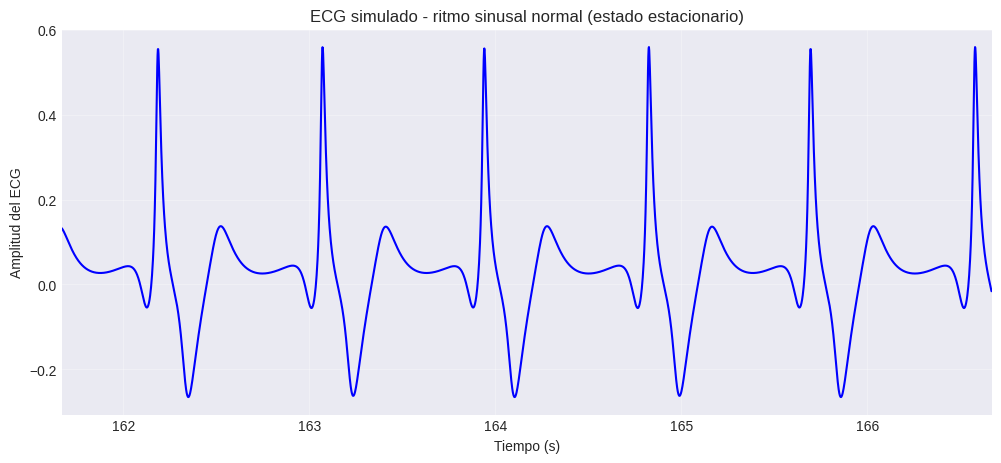

In [21]:
# Calcular el ECG a partir de la solución en estado estacionario
ecg_raw = alpha[0]*x1_steady + alpha[1]*x2_steady + alpha[2]*x3_steady + alpha[3]*x4_steady

# Convertir a tiempo real
t_real_steady = t_steady / Gamma_t

plt.figure(figsize=(12, 5))
plt.plot(t_real_steady, ecg_raw, 'b-', linewidth=1.5)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud del ECG')
plt.title('ECG simulado - ritmo sinusal normal (estado estacionario)')
plt.grid(True, alpha=0.3)
# Se corrigió el t_real_plot no definido y se escaló la ventana para mostrar ~4-5 latidos
plt.xlim(t_real_steady[0], t_real_steady[0] + 5)  
plt.show()

## Obtención de datos de ECG del mundo real

Para validar y ajustar el modelo conformable, se necesita un conjunto de datos de referencia. Para ello se utiliza la base de datos **MIT-BIH Normal Sinus Rhythm Database (nsrdb)** a la que se accede a través de PhysioNet. Dicha base contiene grabaciones de ECG a largo plazo de sujetos que fueron remitidos al Laboratorio de Arritmias pero que no presentaron arritmias significativas.

Específicamente, se extrae una ventana de 10 segundos del Registro `16265`. Esta base de datos proporciona grabaciones de grado clínico de ritmos sinusales normales estándar, muestreados a 128 Hz. 

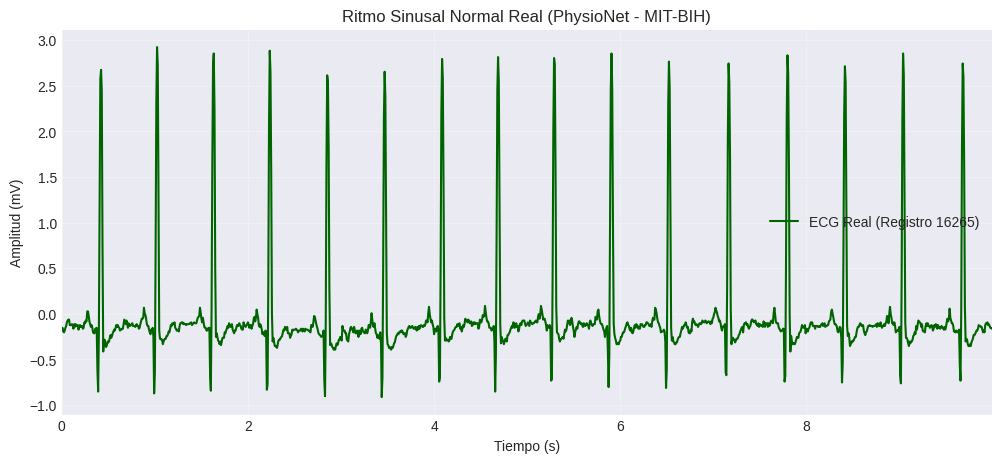

In [22]:
# Usaremos la base de datos MIT-BIH de ritmo sinusal normal ('nsrdb')
# '16265' es un registro de paciente estándar en esta base de datos
record_name = '16265' 

# La frecuencia de muestreo (fs) para nsrdb es de 128 Hz. 
# Para obtener 10 segundos de datos, necesitamos 10 * 128 = 1280 muestras.
try:
    # Descargar el registro directamente desde el servidor de PhysioNet
    record = wfdb.rdrecord(record_name, pn_dir='nsrdb', sampfrom=0, sampto=1280)
    
    # Extraer la señal y el arreglo de tiempo
    # record.p_signal es un arreglo 2D [muestras, canales]. Tomaremos el primer canal.
    real_ecg = record.p_signal[:, 0]
    fs = record.fs
    t_real = np.arange(len(real_ecg)) / fs

    # Graficar el ECG real
    plt.figure(figsize=(12, 5))
    plt.plot(t_real, real_ecg, color='darkgreen', linewidth=1.5, label=f'ECG Real (Registro {record_name})')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (mV)')
    plt.title('Ritmo Sinusal Normal Real (PhysioNet - MIT-BIH)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(t_real[0], t_real[-1])
    plt.show()
    
except Exception as e:
    print(f"Error al obtener los datos: {e}")

## Normalización de la señal y alineación de fase

Antes de comparar la señal simulada con el conjunto de datos real, se deben resolver dos discrepancias fundamentales: la escala y la fase.

1. **Escalamiento de Amplitud**: El ECG clínico se mide en milivoltios, mientras que el modelo matemático produce amplitudes adimensionales arbitrarias. Se aplica la normalización $\min-\max$ para mapear ambas señales a un dominio de $E \in [0, 1]$
   
   $$E_{\text{norm}} = \frac{E - \min(E)}{\max(E) - \min(E)}.$$

2. **Alineación de Fase**: Se utiliza el algoritmo `scipy.signal.find_peaks` para detectar los picos R prominentes (despolarización ventricular) en ambas señales. Al calcular el diferencial de tiempo $\Delta t$ entre los primeros picos R registrados, se desplaza el arreglo de tiempo simulado $t_{\text{sim}}$ para sincronizar las fases

   $$t_{\text{sim}\_\text{aligned}} = t_{\text{sim}} + \Delta t$$

In [23]:
def normalize_signal(signal):
    """Aplica la normalización Min-Max para escalar una señal al rango [0, 1]."""
    return (signal - np.min(signal)) / (np.max(signal) - np.min(signal))

def align_and_normalize(t_real, ecg_real, t_sim, ecg_sim):
    """
    Normaliza ambas señales y desplaza el arreglo de tiempo simulado 
    para que los primeros picos R se alineen perfectamente en el tiempo.
    """
    # 1. Normalizar ambas amplitudes
    real_norm = normalize_signal(ecg_real)
    sim_norm = normalize_signal(ecg_sim)
    
    # 2. Encontrar los picos R (el umbral de altura filtra las ondas P y T más pequeñas)
    # El parámetro de distancia evita encontrar múltiples puntos en el mismo pico
    peaks_real, _ = find_peaks(real_norm, height=0.6, distance=50) 
    peaks_sim, _ = find_peaks(sim_norm, height=0.6, distance=50)
    
    # 3. Extraer el tiempo exacto del primer pico R para ambas señales
    t_peak_real = t_real[peaks_real[0]]
    t_peak_sim = t_sim[peaks_sim[0]]
    
    # 4. Calcular el desplazamiento de tiempo requerido y aplicarlo a la simulación
    time_shift = t_peak_real - t_peak_sim
    t_sim_aligned = t_sim + time_shift
    
    # RETORNAR t_peak_real para poder usarlo en la graficación
    return t_sim_aligned, sim_norm, real_norm, t_peak_real

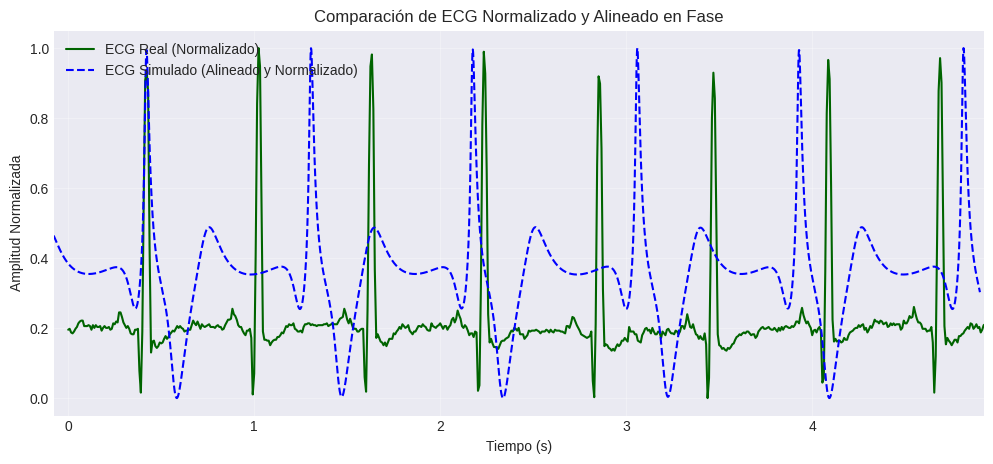

In [24]:
# --- Ejecución y Graficación ---

# Alinear la simulación de estado estacionario del Paso 1 con los datos reales del Paso 2a
t_sim_aligned, sim_norm, real_norm, t_peak_real = align_and_normalize(t_real, real_ecg, t_real_steady, ecg_raw)

plt.figure(figsize=(12, 5))
plt.plot(t_real, real_norm, color='darkgreen', linewidth=1.5, label='ECG Real (Normalizado)')
plt.plot(t_sim_aligned, sim_norm, color='blue', linewidth=1.5, linestyle='--', label='ECG Simulado (Alineado y Normalizado)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud Normalizada')
plt.title('Comparación de ECG Normalizado y Alineado en Fase')
plt.legend()
plt.grid(True, alpha=0.3)

# Limitar la vista a una ventana de superposición limpia usando el tiempo del pico extraído
plt.xlim(t_peak_real - 0.5, t_peak_real + 4.5) 
plt.show()

## Validación del modelo conformable ($\alpha \to 1$)

Antes de optimizar los parámetros para ajustarlos a los datos de PhysioNet, se debe **validar la arquitectura** del modelo conformable. Por la definición de la derivada conformable {eq}`khalil_derivative, a medida que el orden fraccionario $\alpha$ se aproxima a 1, el sistema conformable debe **converger** al sistema de EDO de orden entero. 

Eestableciendo $\alpha = 0.99999$ y una escala de tiempo arbitraria $\sigma = 1.0$. Si la implementación es correcta, el ECG conformable simulado debería superponerse perfectamente al ECG clásico generado en el Paso 1.

In [25]:
# 1. Definir la EDO fraccionaria (si aún no está definida)
def fractional_heart_ode(t, y, C, H, beta, alpha_f, sigma):
    """
    EDO fraccionaria utilizando la derivada conformable.
    Incluye el parámetro dimensional sigma.
    """
    t_safe = max(t, 1e-8) # Prevenir 0^(número negativo)
    frac_modifier = (t_safe / sigma)**(alpha_f - 1)
    
    x1, x2, x3, x4 = y
    
    dx1 = x1 - x2 - C*x1*x2 - x1*x2**2
    dx2 = H*x1 - 3*x2 + C*x1*x2 + x1*x2**2 + beta*(x4 - x2)
    dx3 = x3 - x4 - C*x3*x4 - x3*x4**2
    dx4 = H*x3 - 3*x4 + C*x3*x4 + x3*x4**2 + 2*beta*(x2 - x4)
    
    return [
        dx1 * frac_modifier,
        dx2 * frac_modifier,
        dx3 * frac_modifier,
        dx4 * frac_modifier
    ]

Resolviendo el modelo de validación fraccionario...


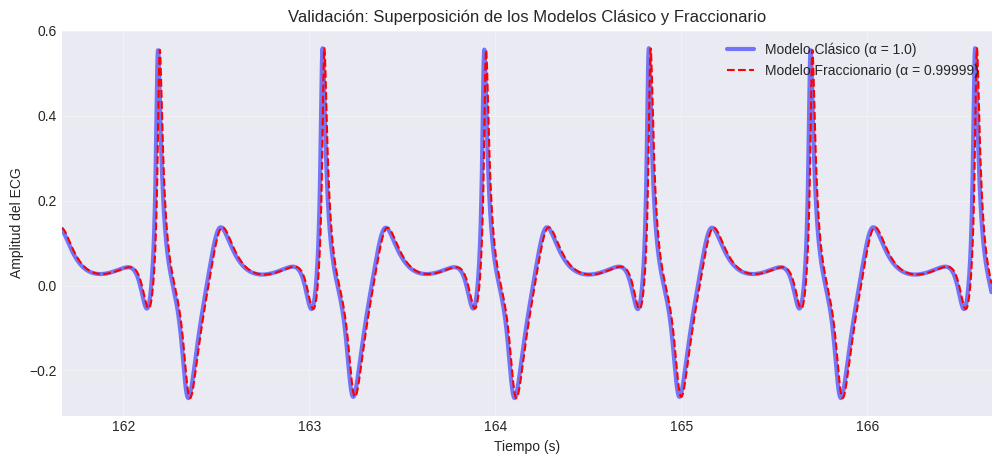

In [26]:

# 2. Establecer los parámetros de validación
alpha_val = 0.99999
sigma_val = 1.0

print("Resolviendo el modelo de validación fraccionario...")

# 3. Resolver el sistema fraccionario utilizando exactamente la misma configuración del Paso 1
sol_frac_val = solve_ivp(
    fractional_heart_ode,
    [t_start, t_end],
    y0, 
    t_eval=t_nondim,
    args=(C, H_normal, beta, alpha_val, sigma_val),
    method='BDF',
    max_step=0.05,
    rtol=1e-6,
    atol=1e-8
)

# 4. Extraer el estado estacionario (usando la misma máscara del Paso 1)
x1_fv, x2_fv, x3_fv, x4_fv = sol_frac_val.y[:, mask]

# 5. Calcular el ECG fraccionario
ecg_frac_val = alpha[0]*x1_fv + alpha[1]*x2_fv + alpha[2]*x3_fv + alpha[3]*x4_fv

# 6. Graficar la superposición
plt.figure(figsize=(12, 5))
# Graficar el modelo clásico (línea azul gruesa)
plt.plot(t_real_steady, ecg_raw, 'b-', linewidth=3, alpha=0.5, label='Modelo Clásico (α = 1.0)')
# Graficar el modelo fraccionario (línea roja discontinua)
plt.plot(t_real_steady, ecg_frac_val, 'r--', linewidth=1.5, label='Modelo Fraccionario (α = 0.99999)')

plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud del ECG')
plt.title('Validación: Superposición de los Modelos Clásico y Fraccionario')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(t_real_steady[0], t_real_steady[0] + 5)
plt.show()

## Optimización de parámetros del modelo cardíaco conformable

Generalizando el modelo clásico de reacción-difusión {eq}`bvam` aplicando la propiedad ${}^{K}\mathcal{D}_{t}^{\alpha}~f(t) = t^{1-\alpha} \frac{\mathrm{d}f}{\mathrm{d}t}$ del operador conformable {eq}`khalil_derivative`, el sistema de ecuaciones se puede reescribir como un sistema de EDOs de primer orden con un coeficiente variable en el tiempo. 

Para mantener la **consistencia dimensional**, introducimos un parámetro de escala temporal, $\sigma$

$$\frac{\mathrm{d}x_i}{\mathrm{d}t} = \left(\frac{t}{\sigma}\right)^{\alpha_{f} - 1} F_i(x).$$

Utilizando `scipy.optimize.differential_evolution` para navegar por el espacio de parámetros y encontrar los valores óptimos del orden fraccionario ($\alpha_f$) y la dimensión temporal ($\sigma$) que minimicen el **Error Cuadrático Medio (MSE)** entre la forma de onda simulada y el ECG real de PhysioNet.

Antes de la optimización, se mide la frecuencia cardíaca real del modelo clásico y la del ECG real de forma independiente. Esto permite determinar:

* **a)** La magnitud del desajuste de frecuencia actual.
* **b)** El valor que debe tener $\Gamma_t$ para cerrar esa brecha analíticamente.

El factor $\Gamma_t$ convierte el tiempo adimensional en segundos reales: $t_{\text{real}} = t_{\text{nondim}} / \Gamma_t$.

Por lo tanto

$$RR_{\text{real}} [s] = \frac{RR_{\text{nondim}} [\text{nondim}]}{\Gamma_t} \implies \Gamma_{t, \text{optimo}} = \frac{RR_{\text{nondim}}}{RR_{\text{real}}}.$$

In [27]:
# Diagnóstico de la Frecuencia Cardíaca

# --- Medir el intervalo R-R del modelo CLÁSICO en tiempo adimensional ---
# Usamos t_steady y ecg_raw de la sección 2.4/2.5 (ya calculados)
ecg_classical_norm = normalize_signal(ecg_raw)

# distance=50 corresponde a 50 muestras en t_steady; verificamos que tenga sentido:
# t_steady tiene ~3000 muestras en ~30 unidades adimensionales → ~100 muestras/unidad adimensional
# A ~5 unidades adimensionales/latido, la distancia mínima = 5*100*0.5 = 250 muestras
# Calculamos la tasa de muestreo real del arreglo de estado estacionario para ser precisos
fs_classical_nondim = len(t_steady) / (t_steady[-1] - t_steady[0])  # muestras por unidad adimensional
min_rr_nondim = 2.5  # intervalo R-R mínimo plausible en unidades adimensionales (corazón muy rápido)

peaks_classical, _ = find_peaks(
    ecg_classical_norm,
    height=0.6,
    distance=int(min_rr_nondim * fs_classical_nondim),
)

if len(peaks_classical) < 2:
    print("ADVERTENCIA: se encontraron menos de 2 picos en el modelo clásico — intente bajar el umbral de altura")

else:
    RR_nondim_values = np.diff(t_steady[peaks_classical])
    RR_nondim_mean = np.mean(RR_nondim_values)
    print(f"Intervalo R-R del modelo clásico (adimensional): {RR_nondim_mean:.3f} ± {np.std(RR_nondim_values):.3f}")
    print(f"Frecuencia cardíaca del modelo clásico (con Gamma_t={Gamma_t}): "
          f"{60 / (RR_nondim_mean / Gamma_t):.1f} lpm")

# --- Medir el intervalo R-R del ECG REAL ---
# t_real está en segundos (de la sección 2.6), real_ecg es mV sin procesar
real_norm_full = normalize_signal(real_ecg)
fs_real = 128  # Hz — frecuencia fija según el registro de PhysioNet

peaks_real_all, _ = find_peaks(
    real_norm_full,
    height=0.6,
    distance=int(0.4 * fs_real),  # 400 ms de R-R mínimo → 150 lpm máx.
)

if len(peaks_real_all) < 2:
    print("ADVERTENCIA: se encontraron menos de 2 picos en el ECG real — intente bajar el umbral de altura")
    
else:
    RR_real_values = np.diff(t_real[peaks_real_all])
    RR_real_mean = np.mean(RR_real_values)
    print(f"\nIntervalo R-R del ECG real: {RR_real_mean:.3f} ± {np.std(RR_real_values):.3f} s")
    print(f"Frecuencia cardíaca del ECG real: {60 / RR_real_mean:.1f} lpm")

    # --- 3. Calcular el Gamma_t óptimo ---
    Gamma_t_optimal = RR_nondim_mean / RR_real_mean

    print(f"\nGamma_t actual:  {Gamma_t:.2f}")
    print(f"Gamma_t óptimo:  {Gamma_t_optimal:.4f}  (ajusta la frecuencia cardíaca a los datos reales)")
    print(f"Cambio relativo:  {100 * (Gamma_t_optimal - Gamma_t) / Gamma_t:+.1f}%")
    print(f"\nUtilizando Gamma_t_optimal = {Gamma_t_optimal:.4f} para todas las optimizaciones posteriores.")

Intervalo R-R del modelo clásico (adimensional): 5.270 ± 0.045
Frecuencia cardíaca del modelo clásico (con Gamma_t=6): 68.3 lpm

Intervalo R-R del ECG real: 0.617 ± 0.013 s
Frecuencia cardíaca del ECG real: 97.2 lpm

Gamma_t actual:  6.00
Gamma_t óptimo:  8.5388  (ajusta la frecuencia cardíaca a los datos reales)
Cambio relativo:  +42.3%

Utilizando Gamma_t_optimal = 8.5388 para todas las optimizaciones posteriores.


### Optimización corregida con frecuencia cardíaca emparejada

Con el desajuste temporal resuelto mediante la introducción de $\Gamma_{\text{t}\_\text{optimal}}$, el algoritmo de optimización ahora está libre de restricciones y puede centrarse exclusivamente en refinar la **morfología** (forma de la onda) del electrocardiograma simulado.

Para proporcionar al optimizador la flexibilidad matemática completa necesaria para explorar el panorama morfológico, los límites de los parámetros se han ampliado significativamente:

* **Orden fraccionario ($\alpha$):** Extendido a $[0.5, 1.0]$.
* **Parámetro de escala temporal ($\sigma$):** Extendido a $[0.1, 500]$.

### Justificación matemática para los límites extendidos de $\sigma$
Durante el ciclo límite de estado estacionario (donde $t_{\text{steady}} \approx 135$), el modificador conformable se evalúa como $(135/\sigma)^{\alpha-1}$. Bajo las restricciones anteriores más estrechas ($\sigma \in [0.1, 10]$), este modificador era estrictamente menor que 1, forzando un efecto de "desaceleración" pura en la derivada. 

Al expandir el límite superior de tal manera que $\sigma > t_{\text{steady}}$, ahora se permite que el modificador sea mayor que 1. Aunque la frecuencia cardíaca macroscópica ya está fijada por $\Gamma_{\text{t}\_\text{optimal}}$, permitir esta "aceleración" teórica otorga al algoritmo la libertad de optimizar completamente las dinámicas transitorias que dictan la forma precisa de la forma de onda cardíaca.

In [28]:
warnings.filterwarnings("ignore")

# Usar el Gamma_t emparejado con la frecuencia cardíaca de la Celda 2.9-A
# Si esa celda falló, se recurre al valor original y se imprime una advertencia
try:
    Gamma_t_fit = Gamma_t_optimal

except NameError:
    print("ADVERTENCIA: Gamma_t_optimal no encontrada — ejecute primero la Celda 2.9-A. Usando Gamma_t original.")
    Gamma_t_fit = Gamma_t

In [29]:
def fractional_heart_ode(t, y, C, H, beta, alpha_f, sigma):
    """
    EDO fraccionaria conformable (Khalil et al. 2014, Teorema 2.2 propiedad 6):
        T_alpha(f)(t) = t^(1 - alpha) * df/dt
    Reorganizando para el solver de PVI:
        df/dt = F(x) * (t/sigma)^(alpha - 1)
    donde sigma otorga consistencia dimensional al tiempo adimensional t.
    """
    t_safe = max(t, 1e-8)
    frac_modifier = (t_safe / sigma) ** (alpha_f - 1)

    x1, x2, x3, x4 = y

    dx1 = x1 - x2 - C * x1 * x2 - x1 * x2 ** 2
    dx2 = H * x1 - 3 * x2 + C * x1 * x2 + x1 * x2 ** 2 + beta * (x4 - x2)
    dx3 = x3 - x4 - C * x3 * x4 - x3 * x4 ** 2
    dx4 = H * x3 - 3 * x4 + C * x3 * x4 + x3 * x4 ** 2 + 2 * beta * (x2 - x4)

    return [dx1 * frac_modifier, dx2 * frac_modifier,
            dx3 * frac_modifier, dx4 * frac_modifier]

def objective_morphology(params):
    """
    Objetivo de morfología de múltiples latidos.

    Dado que la frecuencia cardíaca ya está emparejada a través de Gamma_t_fit, 
    calculamos el MSE sobre la señal completa alineada. Esta es la versión 
    corregida de la sesión 2.9: la simulación se convierte a tiempo real, 
    se alinea con el ECG real mediante el pico R y luego se interpola en la 
    rejilla de 128 Hz del ECG real antes de calcular el MSE.

    Una penalización secundaria por desajuste del intervalo R-R previene que 
    el optimizador encuentre soluciones que deriven accidentalmente en la 
    frecuencia cardíaca durante la ejecución corta de la optimización (donde 
    los efectos transitorios aún pueden ser significativos).
    """
    alpha_f, sigma = params

    t_opt_end = 150
    t_opt_nondim = np.linspace(0, t_opt_end, 15000)

    try:
        sol = solve_ivp(
            fractional_heart_ode,
            [0, t_opt_end],
            y0,
            t_eval=t_opt_nondim,
            args=(C, H_normal, beta, alpha_f, sigma),
            method='BDF',
            max_step=0.05,
            rtol=1e-5,
            atol=1e-7,
        )

        # Estado estacionario: últimas 85 unidades adimensionales
        mask_opt = sol.t >= (t_opt_end - 85)   # ≈ 10 segundos reales con el nuevo Gamma_t
        t_steady_frac = sol.t[mask_opt]
        x1_f, x2_f, x3_f, x4_f = sol.y[:, mask_opt]

        ecg_frac = (alpha[0] * x1_f + alpha[1] * x2_f
                    + alpha[2] * x3_f + alpha[3] * x4_f)

        # Convertir a tiempo real usando el Gamma_t emparejado con la frecuencia cardíaca
        t_real_frac = t_steady_frac / Gamma_t_fit

        # Normalizar
        sim_norm = normalize_signal(ecg_frac)
        real_norm = normalize_signal(real_ecg)

        # --- Encontrar picos R en una base temporal común (ambas en segundos) ---
        fs_sim = len(t_real_frac) / (t_real_frac[-1] - t_real_frac[0])
        min_rr_s = 0.4  # Techo fisiológico de 150 lpm

        peaks_sim, _ = find_peaks(sim_norm,  height=0.6, distance=int(min_rr_s * fs_sim))
        peaks_real, _ = find_peaks(real_norm, height=0.6, distance=int(min_rr_s * 128))

        if len(peaks_sim) < 2 or len(peaks_real) < 2:
            return 1e6

        # --- Penalización por frecuencia cardíaca (secundaria) ---
        # Con Gamma_t_fit ya emparejando las tasas, esto debería ser pequeño.
        # Pero lo incluimos para penalizar soluciones donde el modificador 
        # fraccionario haya alterado significativamente el periodo durante la ejecución.
        RR_sim  = np.mean(np.diff(t_real_frac[peaks_sim]))
        RR_real_meas = np.mean(np.diff(t_real[peaks_real]))
        rr_penalty = ((RR_sim - RR_real_meas) / RR_real_meas) ** 2

        # --- MSE de morfología (primaria) ---
        # Desplazar sim para que el primer pico R coincida con el primer pico R del ECG real
        t_peak_real_val = t_real[peaks_real[0]]
        t_peak_sim_val  = t_real_frac[peaks_sim[0]]
        t_sim_aligned   = t_real_frac + (t_peak_real_val - t_peak_sim_val)

        # Interpolar la simulación alineada en la rejilla de 128 Hz del ECG real
        interp_func = interp1d(t_sim_aligned, sim_norm,
                                bounds_error=False, fill_value=np.nan)
        sim_on_real_grid = interp_func(t_real)

        # Solo evaluar la región de superposición (donde la simulación cubre los datos reales)
        valid = ~np.isnan(sim_on_real_grid)
        if valid.sum() < int(2 * min_rr_s * 128):  # se necesitan al menos ~2 latidos
            return 1e6

        mse = mean_squared_error(real_norm[valid], sim_on_real_grid[valid])

        # Combinación ponderada: 80% morfología, 20% consistencia de frecuencia cardíaca
        return 0.8 * mse + 0.2 * rr_penalty

    except Exception:
        return 1e6

In [30]:
# ─── Ejecutar el optimizador ───────────────────────────────────────────────────
print(f"Gamma_t utilizado para la optimización: {Gamma_t_fit:.4f}")
print(f"Límites: alpha_f ∈ [0.5, 1.0], sigma ∈ [0.1, 500]\n")

# Límites extendidos — especialmente sigma, que ahora abarca tanto modificadores < 1 como > 1
bounds = [(0.5, 1.0), (0.1, 500.0)]

result = differential_evolution(
    objective_morphology,
    bounds,
    strategy='best1bin',
    maxiter=30,       # más iteraciones que antes; 15 eran muy pocas
    popsize=8,        # población ligeramente mayor para un espacio de búsqueda más amplio
    disp=True,
    seed=42,
    tol=1e-6,
    mutation=(0.5, 1.5),
    recombination=0.7,
)

opt_alpha, opt_sigma = result.x
print(f"\n¡Optimización completada!")
print(f"  alpha_f óptimo : {opt_alpha:.4f}")
print(f"  sigma óptimo   : {opt_sigma:.4f}")
print(f"  Modificador en t=135: {(135 / opt_sigma) ** (opt_alpha - 1):.4f}  (1.0 = sin cambios respecto al clásico)")
print(f"  Pérdida mínima : {result.fun:.6f}")

Gamma_t utilizado para la optimización: 8.5388
Límites: alpha_f ∈ [0.5, 1.0], sigma ∈ [0.1, 500]

differential_evolution step 1: f(x)= 0.04505837418620876
differential_evolution step 2: f(x)= 0.039507482187836736
differential_evolution step 3: f(x)= 0.039507482187836736
differential_evolution step 4: f(x)= 0.039507482187836736
differential_evolution step 5: f(x)= 0.03855034332275386
differential_evolution step 6: f(x)= 0.03852890328689787
differential_evolution step 7: f(x)= 0.03852890328689787
differential_evolution step 8: f(x)= 0.03852890328689787
differential_evolution step 9: f(x)= 0.03205524307925268
differential_evolution step 10: f(x)= 0.03197723719502106
differential_evolution step 11: f(x)= 0.03197723719502106
differential_evolution step 12: f(x)= 0.03197412282504667
differential_evolution step 13: f(x)= 0.03197412282504667
differential_evolution step 14: f(x)= 0.03193318789659628
differential_evolution step 15: f(x)= 0.03193318789659628
differential_evolution step 16: f(x)= 

## Visualización del ajuste del modelo conformable

Con los parámetros óptimos identificados mediante Evolución Diferencial ($\alpha \approx 0.9506$, $\sigma \approx 103.3117$), se simula el modelo fraccionario conformable final. 

Para evaluar el ajuste con rigor, se proyecta la forma de onda simulada alineada en fase sobre la cuadrícula temporal experimental utilizando interpolación lineal. Esto permite calcular el error residual punto por punto ($E_{\text{real}} - E_{\text{sim}}$) y computar el error cuadrático medio (RMS) sobre la ventana de observación.

Simulando el modelo fraccionario optimizado para graficación...


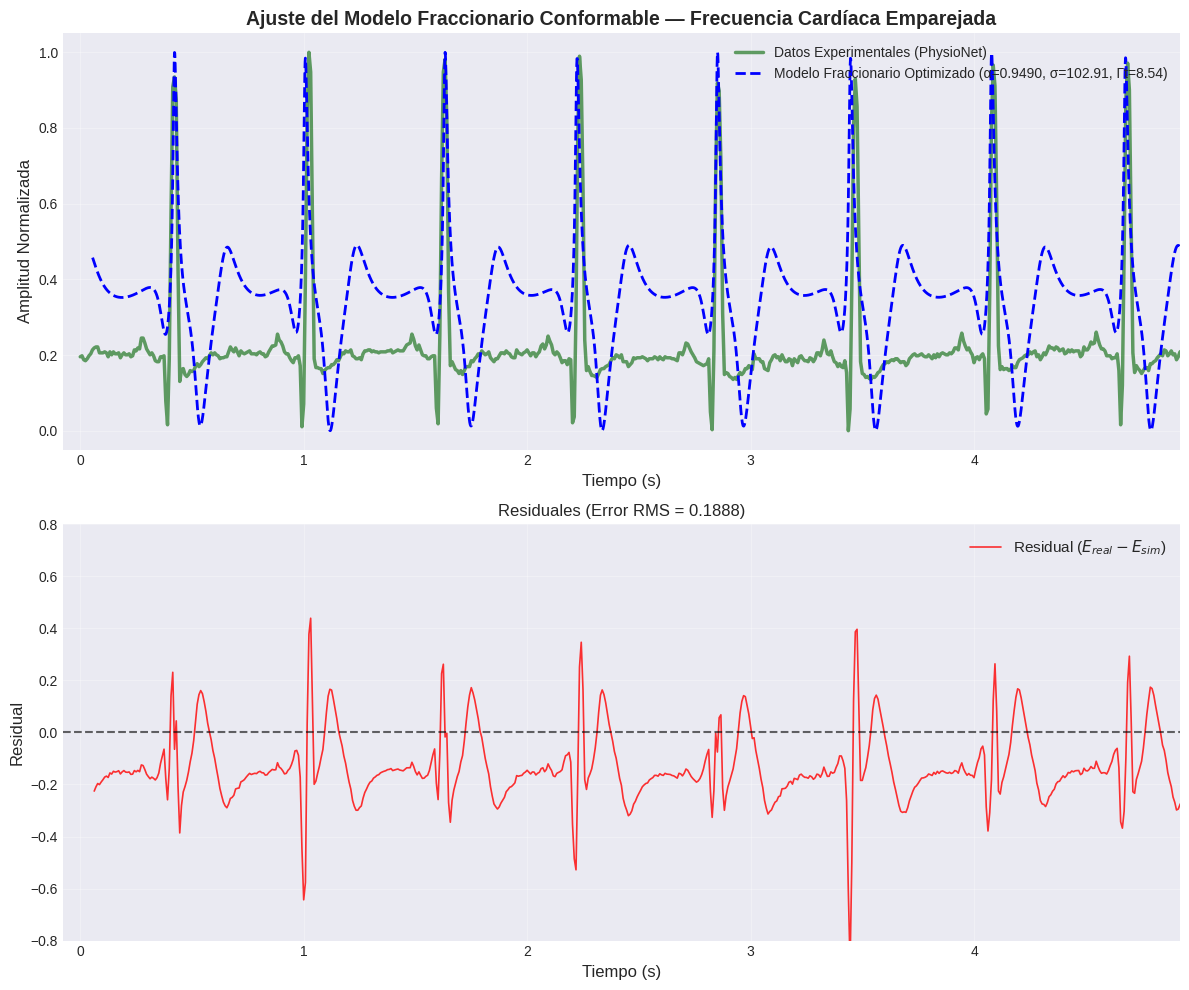


Resumen:
  Error RMS (ventana)   : 0.1888
  Modificador fraccionario : 0.9862
  Frecuencia cardíaca (modelo)  : 97.2 lpm  (objetivo: 97.2 lpm)


In [31]:
# Actualizado para frecuencia cardíaca emparejada

print("Simulando el modelo fraccionario optimizado para graficación...")

t_opt_end = 150
t_opt_nondim = np.linspace(0, t_opt_end, 15000)

sol_opt = solve_ivp(
    fractional_heart_ode,
    [0, t_opt_end],
    y0,
    t_eval=t_opt_nondim,
    args=(C, H_normal, beta, opt_alpha, opt_sigma),
    method='BDF',
    max_step=0.05,
    rtol=1e-6,
    atol=1e-8
)

# Extraer el estado estacionario — usar la ventana extendida coincidente con el optimizador
mask_opt = sol_opt.t >= (t_opt_end - 85)
t_steady_opt = sol_opt.t[mask_opt]
x1_o, x2_o, x3_o, x4_o = sol_opt.y[:, mask_opt]

ecg_opt = alpha[0]*x1_o + alpha[1]*x2_o + alpha[2]*x3_o + alpha[3]*x4_o

# ← CAMBIO CLAVE: usar Gamma_t_fit (= 8.5388) en lugar de Gamma_t (= 6)
t_real_opt = t_steady_opt / Gamma_t_fit

# Alinear y normalizar
t_sim_aligned, sim_norm, real_norm, t_peak_real = align_and_normalize(
    t_real, real_ecg, t_real_opt, ecg_opt
)

# Interpolar para obtener los residuales
sim_interp_func = interp1d(t_sim_aligned, sim_norm, bounds_error=False, fill_value=np.nan)
sim_opt_interp  = sim_interp_func(t_real)
residuals       = real_norm - sim_opt_interp

window_start = t_peak_real - 0.5
window_end   = t_peak_real + 4.5

window_mask = (t_real >= window_start) & (t_real <= window_end) & ~np.isnan(residuals)
rms_error   = np.sqrt(np.mean(residuals[window_mask]**2))

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

ax = axes[0]
ax.plot(t_real, real_norm, color='darkgreen', linewidth=2.5, alpha=0.6,
        label='Datos Experimentales (PhysioNet)')
ax.plot(t_sim_aligned, sim_norm, color='blue', linestyle='--', linewidth=2,
        label=f'Modelo Fraccionario Optimizado (α={opt_alpha:.4f}, σ={opt_sigma:.2f}, Γt={Gamma_t_fit:.2f})')
ax.set_xlabel('Tiempo (s)', fontsize=12)
ax.set_ylabel('Amplitud Normalizada', fontsize=12)
ax.set_title('Ajuste del Modelo Fraccionario Conformable — Frecuencia Cardíaca Emparejada', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(window_start, window_end)

ax = axes[1]
ax.plot(t_real, residuals, color='red', linewidth=1.2, alpha=0.8,
        label='Residual ($E_{real} - E_{sim}$)')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.6)
ax.set_xlabel('Tiempo (s)', fontsize=12)
ax.set_ylabel('Residual', fontsize=12)
ax.set_title(f'Residuales (Error RMS = {rms_error:.4f})', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(window_start, window_end)
ax.set_ylim(-0.8, 0.8)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nResumen:")
print(f"  Error RMS (ventana)   : {rms_error:.4f}")
print(f"  Modificador fraccionario : {(135 / opt_sigma)**(opt_alpha - 1):.4f}")
print(f"  Frecuencia cardíaca (modelo)  : {60 / (5.270 / Gamma_t_fit):.1f} lpm  (objetivo: 97.2 lpm)")

## Optimización de la morfología de un solo latido

Tras haber ajustado los parámetros clásicos ($H$ y $\Gamma_t$) para alinear la frecuencia fundamental (LPM) del modelo con los datos experimentales, ahora se optimizan los parámetros fraccionarios ($\alpha, \sigma$) para ajustarlos a la morfología específica del latido cardíaco.

Para evitar que cualquier desfase residual afecte al Error Cuadrático Medio (MSE), se aisla exactamente un latido (de pico R a pico R) tanto del ECG simulado como del real. Mapeando ambos latidos en un dominio temporal normalizado $T \in [0, 1]$. El optimizador busca entonces los parámetros fraccionarios que mejor moldeen las ondas simuladas P, Q, R, S y T para que coincidan con los datos clínicos.

In [32]:
# ==============================================================================
# Extracción de la Morfología de un Solo Latido y Alineación de Fase
# ==============================================================================
warnings.filterwarnings("ignore")

# 1. Función Auxiliar: Extraer y Ajustar Temporalmente un Solo Latido
def extract_single_beat(ecg_signal):
    """
    Aísla un solo latido cardíaco de un trazado de ECG continuo y normaliza 
    su dominio temporal a T en [0, 1]. Esta aislación evita que el desplazamiento 
    de fase acumulativo sesgue los cálculos de error morfológico durante la optimización.
    
    Parámetros:
    ecg_signal : arreglo
        Los valores de amplitud crudos del trazado de ECG.
        
    Retorna:
    tuple (beat_time, beat_amplitude)
        El arreglo de tiempo normalizado y el arreglo de amplitud normalizado correspondiente.
    """
    # Normalización Min-Max de la amplitud
    norm_ecg = normalize_signal(ecg_signal)
    
    # Identificar picos R para definir los ciclos cardíacos
    peaks, _ = find_peaks(norm_ecg, height=0.6, distance=50)
    
    # Se necesitan al menos 3 picos para extraer un latido intermedio de forma segura
    if len(peaks) < 3:
        return None, None
        
    # Aislar un latido estable de la región de estado estacionario
    start_idx = peaks[-3]
    end_idx = peaks[-2]
    beat_amplitude = norm_ecg[start_idx:end_idx]
    
    # Mapear el latido aislado a un vector de tiempo estandarizado
    beat_time = np.linspace(0, 1, len(beat_amplitude))
    
    return beat_time, beat_amplitude

# ==============================================================================
# Objetivo de Optimización: Ajuste de Morfología
# ==============================================================================
def optimize_morphology(params):
    """
    Función objetivo para el algoritmo de Evolución Diferencial. 
    Simula el ECG fraccionario, extrae un solo latido, lo alinea con los 
    datos empíricos de PhysioNet mediante interpolación lineal y calcula 
    el Error Cuadrático Medio (MSE) de la forma de onda.
    """
    alpha_f, sigma = params
    
    t_opt_end = 150
    t_opt_nondim = np.linspace(0, t_opt_end, 15000)
    
    try:
        # Simular el modelo BVAM fraccionario
        sol_frac = solve_ivp(
            fractional_heart_ode, [0, t_opt_end], y0, t_eval=t_opt_nondim,
            args=(C, H_normal, beta, alpha_f, sigma),
            method='BDF', max_step=0.05, rtol=1e-4, atol=1e-6
        )
        
        # Verificar la estabilidad del ciclo límite (asegurar que el oscilador no decayó)
        mask = sol_frac.t >= (t_opt_end - 30)
        if (np.max(sol_frac.y[3, mask]) - np.min(sol_frac.y[3, mask])) < 0.5:
            return 1e6
            
        x1_f, x2_f, x3_f, x4_f = sol_frac.y[:, mask]
        # Proyectar las variables de estado en la derivación del ECG
        ecg_frac = alpha[0]*x1_f + alpha[1]*x2_f + alpha[2]*x3_f + alpha[3]*x4_f
        
        # Extraer el latido simulado único
        t_sim_beat, sim_beat = extract_single_beat(ecg_frac)
        
        # Extraer el latido real único (real_ecg es del Paso 2)
        t_real_beat, real_beat = extract_single_beat(real_ecg)
        
        if sim_beat is None or real_beat is None:
            return 1e6
            
        # Ajustar temporalmente el latido simulado a la rejilla experimental mediante interpolación
        interp_func = interp1d(t_sim_beat, sim_beat, kind='linear')
        sim_beat_aligned = interp_func(t_real_beat)
        
        # Calcular el error morfológico puro
        mse = mean_squared_error(real_beat, sim_beat_aligned)
        
        return mse
        
    except Exception as e:
        return 1e6

In [33]:
# 3. Ejecución
print("Iniciando la Optimización de la Morfología de un Solo Latido...")

# Acotando alpha cerca de 1 y otorgando a sigma un rango amplio
bounds = [(0.85, 1.0), (0.1, 20.0)]

result_morph = differential_evolution(
    optimize_morphology, 
    bounds, 
    strategy='best1bin', 
    maxiter=15,
    popsize=5, 
    disp=True
)

opt_alpha_m, opt_sigma_m = result_morph.x
print(f"\n¡Optimización Completada!")
print(f"Alpha Óptimo (α): {opt_alpha_m:.4f}")
print(f"Sigma Óptimo (σ): {opt_sigma_m:.4f}")
print(f"MSE de Morfología Final: {result_morph.fun:.6f}")

Iniciando la Optimización de la Morfología de un Solo Latido...
differential_evolution step 1: f(x)= 0.03135315974659421
Polishing solution with 'L-BFGS-B'

¡Optimización Completada!
Alpha Óptimo (α): 0.9846
Sigma Óptimo (σ): 13.0139
MSE de Morfología Final: 0.031287


Graficando la morfología del latido único optimizado...


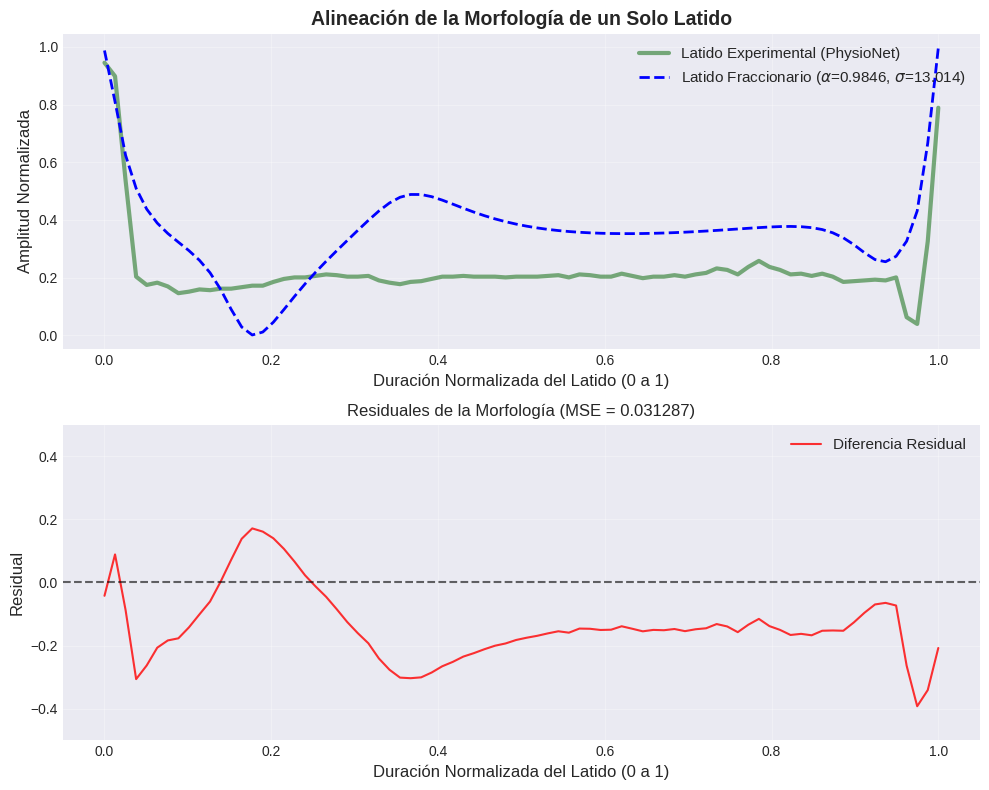

In [34]:
print("Graficando la morfología del latido único optimizado...")

# 1. Ejecutar el modelo óptimo
t_opt_end = 150
t_opt_nondim = np.linspace(0, t_opt_end, 15000)

sol_opt = solve_ivp(
    fractional_heart_ode, [0, t_opt_end], y0, t_eval=t_opt_nondim,
    args=(C, H_normal, beta, opt_alpha_m, opt_sigma_m),
    method='BDF', max_step=0.05, rtol=1e-6, atol=1e-8
)

mask_opt = sol_opt.t >= (t_opt_end - 30)
x1_o, x2_o, x3_o, x4_o = sol_opt.y[:, mask_opt]
ecg_opt = alpha[0]*x1_o + alpha[1]*x2_o + alpha[2]*x3_o + alpha[3]*x4_o

# 2. Extraer ambos latidos
t_sim_beat, sim_beat = extract_single_beat(ecg_opt)
t_real_beat, real_beat = extract_single_beat(real_ecg)

# 3. Interpolar la simulación para graficación/residuales
interp_func = interp1d(t_sim_beat, sim_beat, kind='linear')
sim_beat_aligned = interp_func(t_real_beat)
residuals = real_beat - sim_beat_aligned

# --- Graficación ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Superior: Superposición de la Morfología
ax = axes[0]
ax.plot(t_real_beat, real_beat, color='darkgreen', linewidth=3, alpha=0.5, label='Latido Experimental (PhysioNet)')
ax.plot(t_real_beat, sim_beat_aligned, color='blue', linestyle='--', linewidth=2, label=f'Latido Fraccionario ($\\alpha$={opt_alpha_m:.4f}, $\\sigma$={opt_sigma_m:.3f})')
ax.set_xlabel('Duración Normalizada del Latido (0 a 1)', fontsize=12)
ax.set_ylabel('Amplitud Normalizada', fontsize=12)
ax.set_title('Alineación de la Morfología de un Solo Latido', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=11)

# Inferior: Residuales
ax = axes[1]
ax.plot(t_real_beat, residuals, color='red', linewidth=1.5, alpha=0.8, label='Diferencia Residual')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.6)
ax.set_xlabel('Duración Normalizada del Latido (0 a 1)', fontsize=12)
ax.set_ylabel('Residual', fontsize=12)
ax.set_title(f'Residuales de la Morfología (MSE = {result_morph.fun:.6f})', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 0.5)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

## Comparación del modelo clásica vs. modelo conformable

Para demostrar de manera definitiva el valor de la **derivada conformable** en el modelado de sistemas biológicos, se debe comparar su desempeño directamente con el modelo clásico de orden entero. 

En este paso final, se simula un único latido utilizando los parámetros clásicos ($\alpha = 1.0$) y se inspecciona su comportamiento frente al modelo conformable optimizado ($\alpha < 1.0$). Al graficar ambos modelos con respecto a los datos experimentales de **PhysioNet** y calcular sus respectivos Errores Cuadráticos Medios (**MSE**), es posible cuantificar el porcentaje exacto de mejora en la precisión morfológica alcanzado mediante el cálculo fraccionario.

Generando comparación entre el modelo clásico y el fraccionario...


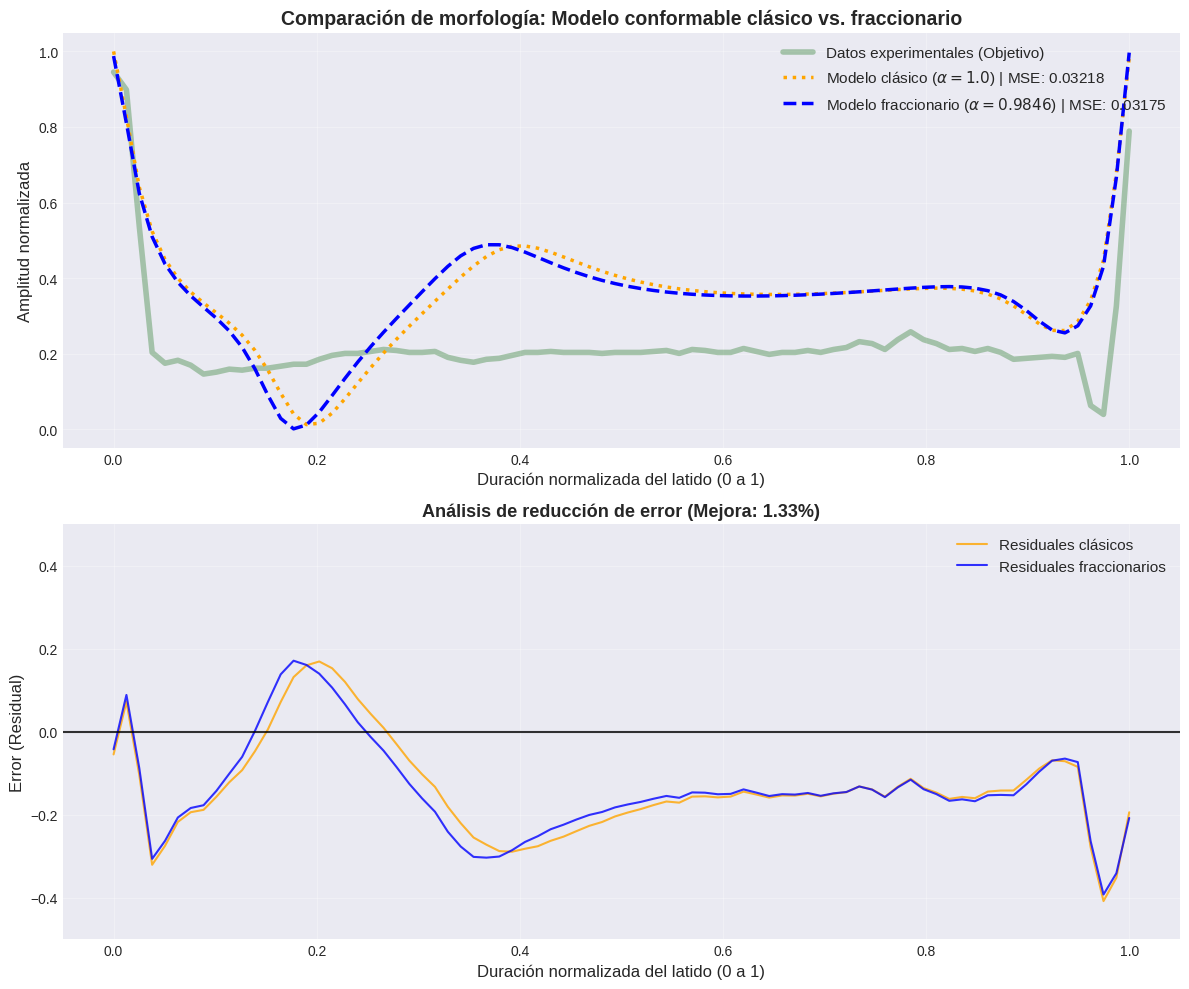

 RESUMEN DEL DESEMPEÑO DEL MODELO
MSE del modelo clásico (α=1.0):      0.032175
MSE del modelo fraccionario (α=0.9846): 0.031749
--------------------------------------------------
El modelo fraccionario mejoró la morfología de la onda en un 1.33%


In [35]:
print("Generando comparación entre el modelo clásico y el fraccionario...")

# --- 1. Generar la línea base clásica (alpha = 1.0, sigma = 1.0) ---
sol_class = solve_ivp(
    fractional_heart_ode, [0, t_opt_end], y0, t_eval=t_opt_nondim,
    args=(C, H_normal, beta, 1.0, 1.0), # Fijado al orden entero clásico
    method='BDF', max_step=0.05, rtol=1e-6, atol=1e-8
)

mask_class = sol_class.t >= (t_opt_end - 30)
x1_c, x2_c, x3_c, x4_c = sol_class.y[:, mask_class]
ecg_class = alpha[0]*x1_c + alpha[1]*x2_c + alpha[2]*x3_c + alpha[3]*x4_c

t_class_beat, class_beat = extract_single_beat(ecg_class)

# Interpolar el latido clásico para que coincida con la longitud del latido real
interp_func_class = interp1d(t_class_beat, class_beat, kind='linear')
class_beat_aligned = interp_func_class(t_real_beat)

# Calcular el error clásico
mse_class = mean_squared_error(real_beat, class_beat_aligned)
residuals_class = real_beat - class_beat_aligned


# --- 2. Generar el modelo fraccionario optimizado (usando opt_alpha_m, opt_sigma_m) ---
sol_frac = solve_ivp(
    fractional_heart_ode, [0, t_opt_end], y0, t_eval=t_opt_nondim,
    args=(C, H_normal, beta, opt_alpha_m, opt_sigma_m),
    method='BDF', max_step=0.05, rtol=1e-6, atol=1e-8
)

mask_frac = sol_frac.t >= (t_opt_end - 30)
x1_f, x2_f, x3_f, x4_f = sol_frac.y[:, mask_frac]
ecg_frac = alpha[0]*x1_f + alpha[1]*x2_f + alpha[2]*x3_f + alpha[3]*x4_f

t_frac_beat, frac_beat = extract_single_beat(ecg_frac)

# Interpolar el latido fraccionario para que coincida con la longitud del latido real
interp_func_frac = interp1d(t_frac_beat, frac_beat, kind='linear')
frac_beat_aligned = interp_func_frac(t_real_beat)

# Calcular el error fraccionario
mse_frac = mean_squared_error(real_beat, frac_beat_aligned)
residuals_frac = real_beat - frac_beat_aligned


# --- 3. Calcular la mejora ---
improvement_pct = ((mse_class - mse_frac) / mse_class) * 100


# --- 4. Graficación de la comparación ---
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Superior: Superposición de la morfología (comparación de 3 vías)
ax = axes[0]
ax.plot(t_real_beat, real_beat, color='darkgreen', linewidth=4, alpha=0.3, label='Datos experimentales (Objetivo)')
ax.plot(t_real_beat, class_beat_aligned, color='orange', linestyle=':', linewidth=2.5, label=f'Modelo clásico ($\\alpha=1.0$) | MSE: {mse_class:.5f}')
ax.plot(t_real_beat, frac_beat_aligned, color='blue', linestyle='--', linewidth=2.5, label=f'Modelo fraccionario ($\\alpha={opt_alpha_m:.4f}$) | MSE: {mse_frac:.5f}')

ax.set_xlabel('Duración normalizada del latido (0 a 1)', fontsize=12)
ax.set_ylabel('Amplitud normalizada', fontsize=12)
ax.set_title('Comparación de morfología: Modelo conformable clásico vs. fraccionario', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=11)

# Inferior: Comparación de residuales
ax = axes[1]
ax.plot(t_real_beat, residuals_class, color='orange', linewidth=1.5, alpha=0.8, label='Residuales clásicos')
ax.plot(t_real_beat, residuals_frac, color='blue', linewidth=1.5, alpha=0.8, label='Residuales fraccionarios')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.8)

ax.set_xlabel('Duración normalizada del latido (0 a 1)', fontsize=12)
ax.set_ylabel('Error (Residual)', fontsize=12)
ax.set_title(f'Análisis de reducción de error (Mejora: {improvement_pct:.2f}%)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 0.5)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# --- 5. Imprimir resumen ---
print("="*50)
print(" RESUMEN DEL DESEMPEÑO DEL MODELO")
print("="*50)
print(f"MSE del modelo clásico (α=1.0):      {mse_class:.6f}")
print(f"MSE del modelo fraccionario (α={opt_alpha_m:.4f}): {mse_frac:.6f}")
print("-" * 50)
if improvement_pct > 0:
    print(f"El modelo fraccionario mejoró la morfología de la onda en un {improvement_pct:.2f}%")
else:
    print(f"El desempeño del modelo fraccionario fue un {abs(improvement_pct):.2f}% inferior (Verificar límites de optimización).")
print("="*50)